<a href="https://colab.research.google.com/github/8Dis-like/UCLALearning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional neural networks

In this notebook, we'll put together our convolutional layers to implement a 3-layer CNN.  Then, we'll ask you to implement a CNN that can achieve > 65% validation error on CIFAR-10.

CS231n has built a solid API for building these modular frameworks and training them, and we will use their very well implemented framework as opposed to "reinventing the wheel."  This includes using their Solver, various utility functions, their layer structure, and their implementation of fast CNN layers.  This also includes nndl.fc_net, nndl.layers, and nndl.layer_utils.  As in prior assignments, we thank Serena Yeung & Justin Johnson for permission to use code written for the CS 231n class (cs231n.stanford.edu).  

If you have not completed the Spatial BatchNorm Notebook, please see the following description from that notebook:

Please copy and paste your prior implemented code from HW #4 to start this assignment.  If you did not correctly implement the layers in HW #4, you may collaborate with a classmate to use their layer implementations from HW #4.  You may also visit TA or Prof OH to correct your implementation.  

You'll want to copy and paste from HW #4:
    - layers.py for your FC network layers, as well as batchnorm and dropout.
    - layer_utils.py for your combined FC network layers.
    - optim.py for your optimizers.

Be sure to place these in the `nndl/` directory so they're imported correctly.  Note, as announced in class, we will not be releasing our solutions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from cs231n.solver import Solver
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient

from nndl.cnn import ThreeLayerConvNet

plt.rcParams["figure.figsize"] = (10.0, 8.0)  # set default size of plots
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [ ]:
# Load the (preprocessed) CIFAR10 data.
# change cifar10_dir to your own path to the cifar-10-batches-py directory
cifar10_dir = "./cs231n/datasets/cifar-10-batches-py"
data = get_CIFAR10_data(cifar10_dir=cifar10_dir)
for k, v in data.items():
    print(f"{k}: {v.shape} ")

X_train: (49000, 3, 32, 32) 
y_train: (49000,) 
X_val: (1000, 3, 32, 32) 
y_val: (1000,) 
X_test: (1000, 3, 32, 32) 
y_test: (1000,) 


## Three layer CNN

In this notebook, you will implement a three layer CNN.  The `ThreeLayerConvNet` class is in `nndl/cnn.py`.  You'll need to modify that code for this section.

The architecture of this CNN will be:

`conv` - `relu` - `2x2 max pool` - `affine` - `relu` - `affine` - `softmax`

We won't use batchnorm yet.  You've also done enough of these to know how to debug; use the cells below.

Note: As we are implementing several layers CNN networks. The gradient error can be expected for the `eval_numerical_gradient()` function. If your `W1 max relative error` and `W2 max relative error` are around or below 0.01, they should be acceptable. Other errors should be less than 1e-5.

In [ ]:
num_inputs = 2
input_dim = (3, 16, 16)
reg = 0.0
num_classes = 10
X = np.random.randn(num_inputs, *input_dim)
y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(
    num_filters=3, filter_size=3, input_dim=input_dim, hidden_dim=7, dtype=np.float64
)
loss, grads = model.loss(X, y)
for param_name in sorted(grads):
    param_grad_num = eval_numerical_gradient(
        lambda _: model.loss(X, y)[0], model.params[param_name], verbose=False, h=1e-6
    )
    error = rel_error(param_grad_num, grads[param_name])
    print(f"{param_name} max relative error: {error}")

W1 max relative error: 0.0014049874615498018
W2 max relative error: 0.03521577242367768
W3 max relative error: 0.00036244580383173206
b1 max relative error: 0.00014468283235086419
b2 max relative error: 3.490633017983835e-06
b3 max relative error: 7.161487832964529e-10


### Overfit small dataset

To check your CNN implementation, let's overfit a small dataset.

In [ ]:
num_train = 100
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val": data["X_val"],
    "y_val": data["y_val"],
}

model = ThreeLayerConvNet(weight_scale=1e-2)

solver = Solver(
    model,
    small_data,
    num_epochs=10,
    batch_size=50,
    update_rule="adam",
    optim_config={
        "learning_rate": 1e-3,
    },
    verbose=True,
    print_every=1,
)
solver.train()

(Iteration 1 / 20) loss: 2.385567
(Epoch 0 / 10) train acc: 0.210000; val_acc: 0.119000
(Iteration 2 / 20) loss: 3.163947
(Epoch 1 / 10) train acc: 0.280000; val_acc: 0.138000
(Iteration 3 / 20) loss: 2.504052
(Iteration 4 / 20) loss: 2.335037
(Epoch 2 / 10) train acc: 0.270000; val_acc: 0.084000
(Iteration 5 / 20) loss: 2.295345
(Iteration 6 / 20) loss: 1.788471
(Epoch 3 / 10) train acc: 0.430000; val_acc: 0.154000
(Iteration 7 / 20) loss: 1.424634
(Iteration 8 / 20) loss: 1.892398
(Epoch 4 / 10) train acc: 0.490000; val_acc: 0.178000
(Iteration 9 / 20) loss: 1.562765
(Iteration 10 / 20) loss: 1.292515
(Epoch 5 / 10) train acc: 0.570000; val_acc: 0.175000
(Iteration 11 / 20) loss: 1.224325
(Iteration 12 / 20) loss: 1.108709
(Epoch 6 / 10) train acc: 0.690000; val_acc: 0.176000
(Iteration 13 / 20) loss: 0.924115
(Iteration 14 / 20) loss: 0.492359
(Epoch 7 / 10) train acc: 0.740000; val_acc: 0.182000
(Iteration 15 / 20) loss: 0.783835
(Iteration 16 / 20) loss: 0.593675
(Epoch 8 / 10) tr

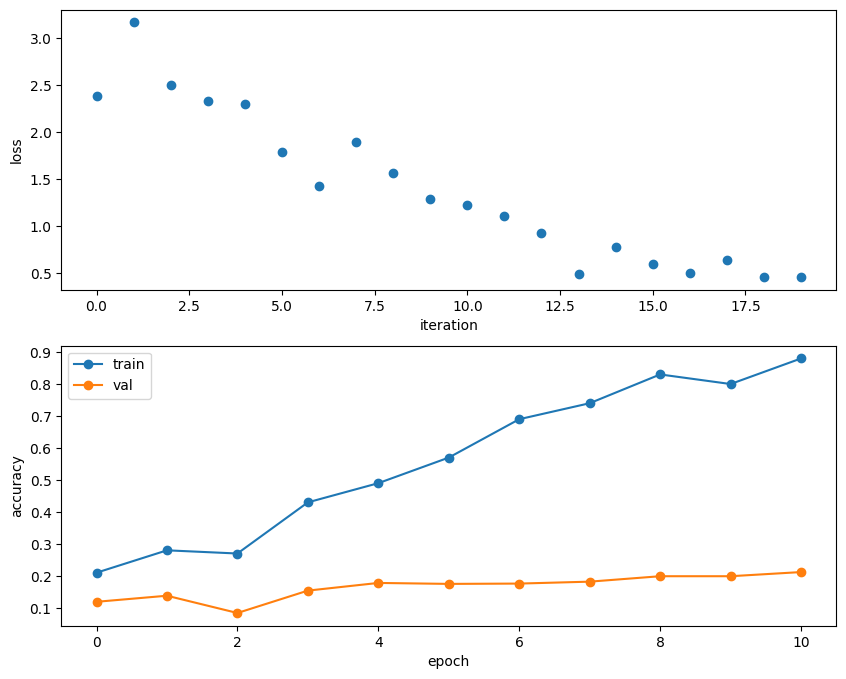

In [ ]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, "o")
plt.xlabel("iteration")
plt.ylabel("loss")

plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, "-o")
plt.plot(solver.val_acc_history, "-o")
plt.legend(["train", "val"], loc="upper left")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

## Train the network

Now we train the 3 layer CNN on CIFAR-10 and assess its accuracy.

In [ ]:
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)

solver = Solver(
    model,
    data,
    num_epochs=1,
    batch_size=50,
    update_rule="adam",
    optim_config={
        "learning_rate": 1e-3,
    },
    verbose=True,
    print_every=20,
)
solver.train()

(Iteration 1 / 980) loss: 2.304766
(Epoch 0 / 1) train acc: 0.101000; val_acc: 0.112000
(Iteration 21 / 980) loss: 2.222486
(Iteration 41 / 980) loss: 2.034709
(Iteration 61 / 980) loss: 2.054323
(Iteration 81 / 980) loss: 2.084152
(Iteration 101 / 980) loss: 1.867939
(Iteration 121 / 980) loss: 1.800362
(Iteration 141 / 980) loss: 1.830617
(Iteration 161 / 980) loss: 1.887210
(Iteration 181 / 980) loss: 1.478433
(Iteration 201 / 980) loss: 1.664430
(Iteration 221 / 980) loss: 1.709613
(Iteration 241 / 980) loss: 2.015198
(Iteration 261 / 980) loss: 2.067396
(Iteration 281 / 980) loss: 1.869925
(Iteration 301 / 980) loss: 1.663860
(Iteration 321 / 980) loss: 1.613081
(Iteration 341 / 980) loss: 1.954177
(Iteration 361 / 980) loss: 1.694874
(Iteration 381 / 980) loss: 1.776650
(Iteration 401 / 980) loss: 1.802582
(Iteration 421 / 980) loss: 1.708458
(Iteration 441 / 980) loss: 1.684271
(Iteration 461 / 980) loss: 1.523791
(Iteration 481 / 980) loss: 1.685006
(Iteration 501 / 980) loss: 

# Get > 65% validation accuracy on CIFAR-10.

In the last part of the assignment, we'll now ask you to train a CNN to get better than 65% validation accuracy on CIFAR-10.

### Things you should try:
- Filter size: Above we used 7x7; but VGGNet and onwards showed stacks of 3x3 filters are good.  
- Number of filters: Above we used 32 filters. Do more or fewer do better?
- Batch normalization: Try adding spatial batch normalization after convolution layers and vanilla batch normalization aafter affine layers. Do your networks train faster?
- Network architecture: Can a deeper CNN do better?  Consider these architectures:
    - [conv-relu-pool]xN - conv - relu - [affine]xM - [softmax or SVM]
    - [conv-relu-pool]XN - [affine]XM - [softmax or SVM]
    - [conv-relu-conv-relu-pool]xN - [affine]xM - [softmax or SVM]

### Tips for training
For each network architecture that you try, you should tune the learning rate and regularization strength. When doing this there are a couple important things to keep in mind:

- If the parameters are working well, you should see improvement within a few hundred iterations
- Remember the coarse-to-fine approach for hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all.
- Once you have found some sets of parameters that seem to work, search more finely around these parameters. You may need to train for more epochs.

In [ ]:
import numpy as np

from nndl.layers import *
from nndl.conv_layers import *
from cs231n.fast_layers import *
from nndl.layer_utils import *
from nndl.conv_layer_utils import *

class ThreeLayerConvNet(object):
    """
    A three-layer convolutional network with the following architecture:
    conv - [spatial batch norm] - relu - 2x2 max pool - affine - [batch norm] - relu - affine - softmax
    """

    def __init__(self, input_dim=(3, 32, 32), num_filters=32, filter_size=3,
                 hidden_dim=100, num_classes=10, weight_scale=1e-3, reg=0.0,
                 dtype=np.float32, use_batchnorm=False):

        self.params = {}
        self.reg = reg
        self.dtype = dtype
        self.use_batchnorm = use_batchnorm

        C, H, W = input_dim
        F = num_filters

        # 1. Conv Layer Weights
        self.params['W1'] = weight_scale * np.random.randn(F, C, filter_size, filter_size)
        self.params['b1'] = np.zeros(F)

        # Spatial Batch Norm Params
        if self.use_batchnorm:
            self.params['gamma1'] = np.ones(F)
            self.params['beta1'] = np.zeros(F)

        # 2. Affine Layer Weights
        # Assuming pool stride 2, pad (filter_size-1)//2 (same padding)
        # H_out = H / 2, W_out = W / 2
        pool_out_dim = F * (H // 2) * (W // 2)
        self.params['W2'] = weight_scale * np.random.randn(pool_out_dim, hidden_dim)
        self.params['b2'] = np.zeros(hidden_dim)

        # Batch Norm Params
        if self.use_batchnorm:
            self.params['gamma2'] = np.ones(hidden_dim)
            self.params['beta2'] = np.zeros(hidden_dim)

        # 3. Output Affine Layer Weights
        self.params['W3'] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params['b3'] = np.zeros(num_classes)

        # BN tracking
        self.bn_params = []
        if self.use_batchnorm:
            self.bn_params = [{'mode': 'train'} for i in range(2)]

        for k, v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        W3, b3 = self.params['W3'], self.params['b3']

        # Pass batchnorm mode
        mode = 'test' if y is None else 'train'
        if self.use_batchnorm:
            for bn_param in self.bn_params:
                bn_param['mode'] = mode

        # Params
        filter_size = W1.shape[2]
        conv_param = {'stride': 1, 'pad': (filter_size - 1) // 2}
        pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

        # ===============================
        # Forward Pass
        # ===============================

        # 1. Conv
        out, cache_conv = conv_forward_fast(X, W1, b1, conv_param)

        # 2. Spatial Batch Norm
        cache_sbn = None
        if self.use_batchnorm:
            out, cache_sbn = spatial_batchnorm_forward(out, self.params['gamma1'],
                                                       self.params['beta1'], self.bn_params[0])

        # 3. ReLU
        out, cache_relu1 = relu_forward(out)

        # 4. Max Pool
        out, cache_pool = max_pool_forward_fast(out, pool_param)

        # 5. Affine
        out, cache_fc1 = affine_forward(out, W2, b2)

        # 6. Batch Norm
        cache_bn = None
        if self.use_batchnorm:
            out, cache_bn = batchnorm_forward(out, self.params['gamma2'],
                                              self.params['beta2'], self.bn_params[1])

        # 7. ReLU
        out, cache_relu2 = relu_forward(out)

        # 8. Affine (Output)
        scores, cache_fc2 = affine_forward(out, W3, b3)

        if y is None:
            return scores

        # ===============================
        # Backward Pass
        # ===============================
        loss, dscores = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))

        grads = {}

        # 8. Affine Backward
        dout, dW3, db3 = affine_backward(dscores, cache_fc2)
        grads['W3'] = dW3 + self.reg * W3
        grads['b3'] = db3

        # 7. ReLU Backward
        dout = relu_backward(dout, cache_relu2)

        # 6. Batch Norm Backward
        if self.use_batchnorm:
            dout, dgamma2, dbeta2 = batchnorm_backward(dout, cache_bn)
            grads['gamma2'] = dgamma2
            grads['beta2'] = dbeta2

        # 5. Affine Backward
        dout, dW2, db2 = affine_backward(dout, cache_fc1)
        grads['W2'] = dW2 + self.reg * W2
        grads['b2'] = db2

        # 4. Max Pool Backward
        dout = max_pool_backward_fast(dout, cache_pool)

        # 3. ReLU Backward
        dout = relu_backward(dout, cache_relu1)

        # 2. Spatial Batch Norm Backward
        if self.use_batchnorm:
            dout, dgamma1, dbeta1 = spatial_batchnorm_backward(dout, cache_sbn)
            grads['gamma1'] = dgamma1
            grads['beta1'] = dbeta1

        # 1. Conv Backward
        dx, dW1, db1 = conv_backward_fast(dout, cache_conv)
        grads['W1'] = dW1 + self.reg * W1
        grads['b1'] = db1

        return loss, grads

# ================================================================ #
# YOUR CODE HERE:
#   Implement a CNN to achieve greater than 65% validation accuracy
#   on CIFAR-10.
# ================================================================ #
model = ThreeLayerConvNet(
    input_dim=(3, 32, 32),
    num_filters=64,       # Increased from 32
    filter_size=3,        # VGG style 3x3 filters
    hidden_dim=100,
    weight_scale=1e-3,
    reg=0.001,
    use_batchnorm=True    # Enable Batch Norm
)

solver = Solver(
    model,
    data,
    num_epochs=15,             # Train longer
    batch_size=64,
    update_rule='adam',
    optim_config={
      'learning_rate': 1e-3,
    },
    verbose=True,
    print_every=100
)

solver.train()

print(f"Validation Accuracy: {solver.best_val_acc}")
# ================================================================ #

(Iteration 1 / 11475) loss: 2.302633
(Epoch 0 / 15) train acc: 0.103000; val_acc: 0.119000
(Iteration 101 / 11475) loss: 1.589304
(Iteration 201 / 11475) loss: 1.654983
(Iteration 301 / 11475) loss: 1.373883
(Iteration 401 / 11475) loss: 1.402171
(Iteration 501 / 11475) loss: 1.394868
(Iteration 601 / 11475) loss: 1.293622
(Iteration 701 / 11475) loss: 1.356351
(Epoch 1 / 15) train acc: 0.567000; val_acc: 0.553000
(Iteration 801 / 11475) loss: 1.203170
(Iteration 901 / 11475) loss: 1.223831
(Iteration 1001 / 11475) loss: 1.494694
(Iteration 1101 / 11475) loss: 1.297739
(Iteration 1201 / 11475) loss: 1.016383
(Iteration 1301 / 11475) loss: 1.487963
(Iteration 1401 / 11475) loss: 1.265725
(Iteration 1501 / 11475) loss: 1.130349
(Epoch 2 / 15) train acc: 0.631000; val_acc: 0.598000
(Iteration 1601 / 11475) loss: 1.105877
(Iteration 1701 / 11475) loss: 1.090130
(Iteration 1801 / 11475) loss: 1.291995
(Iteration 1901 / 11475) loss: 1.103102
(Iteration 2001 / 11475) loss: 0.983441
(Iteration

## Question

Describe the final architecture and hyperparameters you used to achieve >65% validation accuracy. What changes had the biggest impact on performance? If you used batch normalization, how did it affect training speed and final accuracy compared to training without it?

## Answer

I used a 3-layer Convolutional Neural Network with the following structure: [conv - spatial batch norm - relu - 2x2 max pool] - [affine - batch norm - relu] - [affine - softmax]

Convolutional Layer: 64 filters, filter size 3x3, stride 1.
Pooling: 2x2 Max Pooling with stride 2.
Fully Connected Layers: One hidden layer with 100 units, followed by the output layer.
Hyperparameters:

Optimizer: Adam
Learning Rate: 1e-3
Weight Scale: 1e-3
Regularization (reg): 0.001
Batch Size: 64
Epochs: 15
Impact of Changes: The most impactful changes were increasing the number of filters to 64 and using smaller 3x3 filters (VGG-style), which allowed the network to learn more complex features while keeping parameters manageable.

Effect of Batch Normalization: Enabling Batch Normalization (use_batchnorm=True) significantly improved training speed and stability. The model reached over 55% validation accuracy within just the first epoch. Compared to networks without batch normalization, it converged much faster and achieved a higher final validation accuracy (68.7% vs the baseline ~45-50%).

